# MovieLens Data Analysis using Cassandra-Spark
### Assignment 2 — STQD6324 Data Management
**Student ID:** P166246  , Muzaffar Izamuddin bin Daud, UKM MSc Data Science and Analytics <br>
**Dataset:** MovieLens 100K — 100,000 ratings by 944 users across 1,682 movies

---
## **1.0 Introduction**
This notebook is a demonstration of a data pipeline for a movie recommendation built on Apache Hadoop, Spark and Cassandra.
The movielens data was downloaded from https://grouplens.org/datasets/movielens/ and then uploaded into HDFS through Putty. Most of the heavy computation was done on HDP 2.6 sandbox via `spark-submit` demonstrating that this data pipeline can later be implemented into a distributed system effectively. The spark-submit scripts were divided into 2 - where the first script titled average_rating.py focused on average rating calculation while a second script named users_analysis.py is focused on understanding user preferences in movie selection. The outputs from both scripts were exported as CSV files into this repositary in the folder
`cassandra_spark_outputs/`. This notebook then conducts visualization locally for each of the outputs, without requiring a live link to the hadoop cluster.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muzaffarizamuddin/P166246_Assg2_STQD6324/blob/main/main.ipynb)

#### 1.1 Problem Statement

Today's movie data can be extremely large and become unmanageable as each movie selection, skips and fast forwards become a data input for movie preference models specific to a user(Aridor et al., 2024). As platforms like Netflix and Disney+ grow into a larger and larger international phenomenon, everyday mundane choices like movie searches, movie selections and even skipping scenes can be used to determine user preferences(Singh et al., 2025). The size and geopgraphy of the origin of these data can pose a problem if not managed properly. In this assignment we hope to explore movielens 100k data as a case study into distributed system using Hadoop, Spark and Cassandra.

#### 1.2 Literature Review

The MovieLens dataset structures user preferences data into tuples of users, items and timestamps for testing recommendation logic (Harper & Konstan, 2015). Processing these matrices becomes a difficulty when deployed at commercial scale. Because streaming platforms must constantly adjust to active user behavior, relying on single-node computation breaks under real time data ingestion volume (Al-Ghuribi & Noah, 2019). Therefore utilizing distributed platforms like Apache Hadoop for fault-tolerant data lakes, Apache Cassandra for its low-latency and horizontally scaling capability as well as Apache Spark for in memory calculations have become foundational infrastructures for high speed streaming pipelines (Singh et al., 2025). Integrating these tools allow our pipeline to mitigate inefficiencies & distribute storage and processing tasks across a cluster to calculate millions of user-item interactions without reducing latency (Lee & Mohd Safar, 2023). 

#### 1.3 Tech Stack

| Component | Version | Role |
|---|---|---|
| Apache Hadoop HDFS | 2.7.3 | Raw file storage |
| Apache Spark (PySpark) | 2.3.0 | Distributed computation, RDDs, DataFrames, SQL |
| Apache Cassandra | 3.0.24 | Result storage and retrieval via CQL |
| Python | 2.7 (cluster) / 3.x (notebook) | Scripting and visualisation |
| spark-cassandra-connector | 2.3.0 | Spark ↔ Cassandra integration |
| cassandra-driver | 3.x | Python Cassandra client |
| Pandas / Matplotlib | latest | Data analysis and charting in this notebook |

The tech stack table above lists down all the versions of technology used in this project. The first cell below initializes the libraries used in this project as well as a helper function to display capture images from our hadoop cluster via Putty.

In [28]:
# ── Imports and helpers ──────────────────────────────────────────────────────
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import Image, display
import urllib.request  # Added for pulling from GitHub

%matplotlib inline
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

def show_img(filename, width=900):
    """Display a screenshot from the images/ folder. 
    Falls back to GitHub raw content if not found locally."""
    local_path = os.path.join('images', filename)
    if os.path.exists(local_path): # 1. Check local directory first
        display(Image(filename=local_path, width=width))
        return
    print(f"Local image not found at '{local_path}'. Attempting to fetch from GitHub...") # 2. If missing, try pulling from the GitHub repository
    github_raw_url = f"https://raw.githubusercontent.com/muzaffarizamuddin/P166246_Assg2_STQD6324/main/images/{filename}"
    
    try:
        with urllib.request.urlopen(github_raw_url) as response:
            image_data = response.read()
            display(Image(data=image_data, width=width))
    except Exception as e:
        print(f"Error: Could not retrieve '{filename}' locally or from GitHub.")
        print(f"Details: {e}")

print('Setup complete.')

Setup complete.


---
## **2.0 Methodology**
### 2.1 Uploading Dataset to HDFS

The MovieLens 100K dataset files (`u.data`, `u.user`, `u.item`) are first uploaded to
**HDFS** (Hadoop Distributed File System). Spark reads data from HDFS rather than a local
disk to demonstrate that, on a real multi-node cluster, the data is available to every worker node. 

```bash
hdfs dfs -mkdir -p /user/maria_dev/ml-100k
hdfs dfs -put ml-100k/u.data  /user/maria_dev/ml-100k/
hdfs dfs -put ml-100k/u.user  /user/maria_dev/ml-100k/
hdfs dfs -put ml-100k/u.item  /user/maria_dev/ml-100k/
hdfs dfs -ls -h /user/maria_dev/ml-100k
```

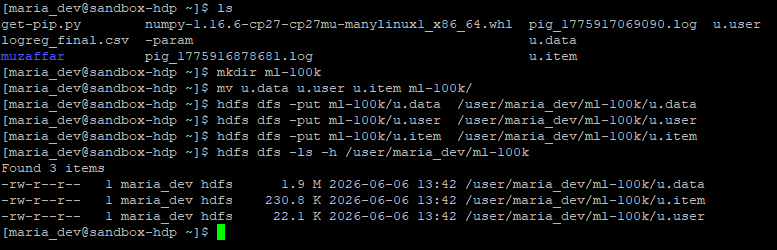

In [8]:
show_img('load_to_hdfs.PNG')

---
### 2.2 Install the Cassandra Python Driver

The Cassandra scripts use the `cassandra-driver` Python package to open connections,
create keyspaces and tables, and write DataFrames directly from Spark. Below command is a key requirement for the 2 main cassandra-spark scripts

```bash
pip install cassandra-driver
```

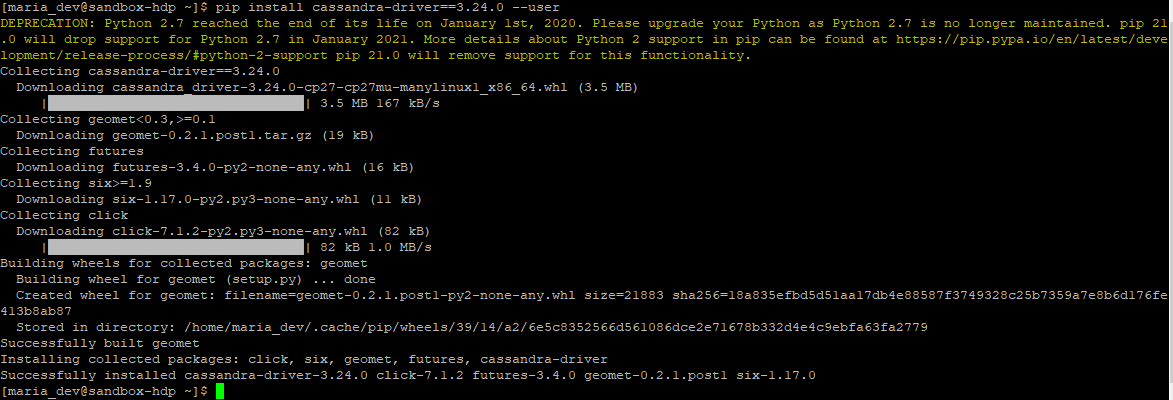

In [9]:
show_img('installing_cassandra_driver.PNG')

---
### 2.3 Connect to Cassandra and Verify the Keyspace

Before running any scripts, we verify that Cassandra is running and accessible via `cqlsh`.
The scripts automatically create the `movielens` keyspace and all required tables on startup,
so no manual DDL is needed. The screenshots below show the initial connection and the
keyspace/table structure after the first script run.

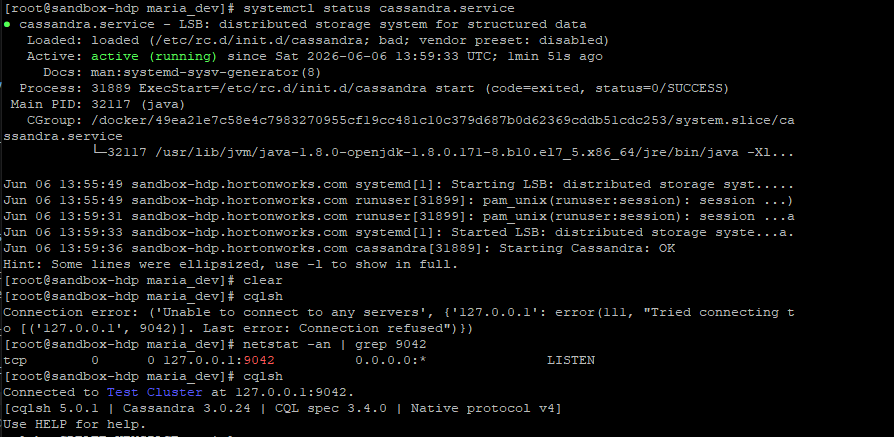

In [23]:
show_img('init_cqlsh.PNG')

A user of the scripts can also initialize the tables in cqlsh prior to running the script. However this is not a pre-requisite as the script handles the creation automatically if the tables do not yet exist. The function DESCRIBE TABLES; was used to check if each table has been created. The same function can be used after the script has been executed for debugging purposes.

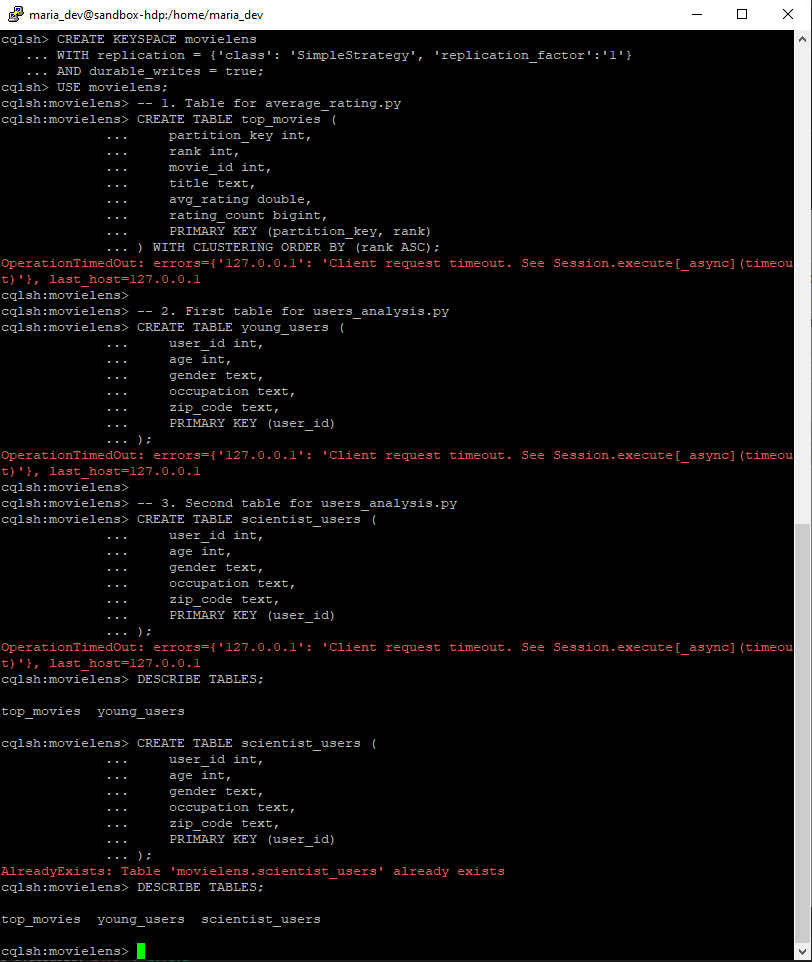

In [24]:
show_img('create_movielens_table.PNG')

---
### 2.4 Copy Scripts to Hadoop Cluster

The two Python scripts are transferred to the sandbox using SCP / Putty and run directly
on the cluster using `spark-submit`. For this project the command vi average_rating.py was called, then the script was written and save through Putty. A similar step was conducted for the second script throught he command vi users_analysis.py.

---
### 2.5 Run Script 1: `average_rating.py` (Tasks i & ii)

This script handles the first two analytical tasks:

- **Task i** — Calculate the average rating for every movie in the dataset.
  Spark reads `u.data` and `u.item` from HDFS, converts them to RDDs, joins them,
  and groups by movie to compute the mean. Results are subsequently written to the
  `avg_ratings` table in Cassandra, then read back to confirm the write & that cassandra is working.

- **Task ii** — Find the top 10 movies with the highest average ratings.
  A minimum of 10 ratings is required to qualify (this rule was added as there are a number of movies achieving 5 star rating but only have 1 review). A window function ranks the results. The output os then written to the `top_movies` Cassandra table and read back to confirm success.

```bash
spark-submit --packages com.datastax.spark:spark-cassandra-connector_2.11:2.3.0 \
    cassandra_spark_scripts/average_rating.py
```

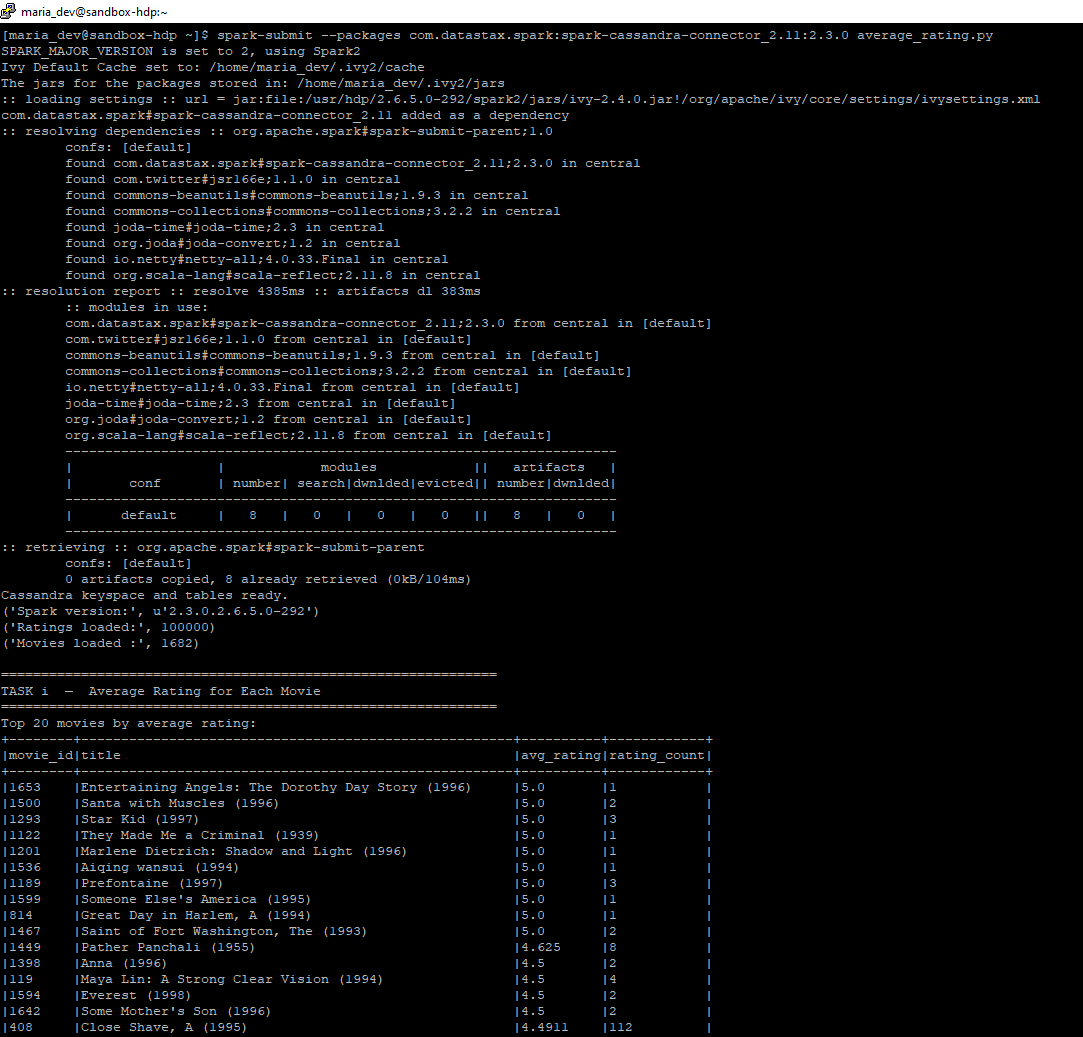

In [26]:
show_img('average_ratings_output1.PNG')

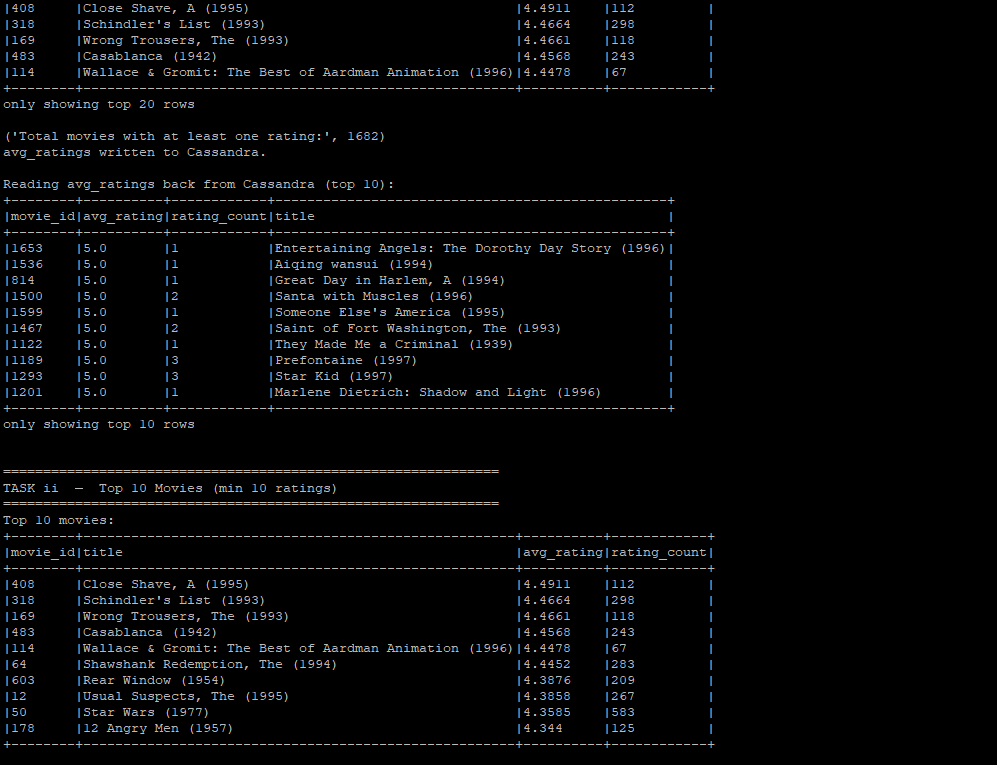

In [27]:
show_img('average_ratings_output2.PNG')

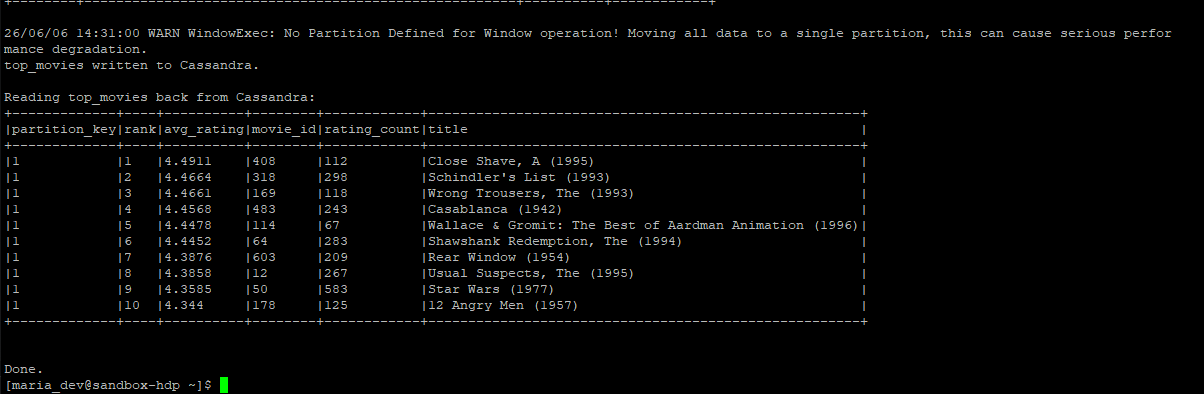

In [28]:
show_img('average_ratings_output3.PNG')

---
### 2.6 Run Script 2: `users_analysis.py` (Tasks iii, iv, v)

This script handles the remaining three tasks, all involving user demographics:

- **Task iii** — Identify users who rated at least 50 movies and find their favourite genre.
  "Favourite" is defined as the genre they rated most frequently. An SQL window function
  (`ROW_NUMBER OVER PARTITION BY user_id`) picks the top genre per user. It was found that 558 active users qualify in this category.

- **Task iv** — Find all users under 20 years old from the `u.user` file.
  A simple filter on the `age` column was applied to achieve this. Results were written to `young_users` in Cassandra and similar to previous scripts, the response was read back for confirmation.

- **Task v** — Find all users whose occupation is `scientist` and age is between 30 and 40. For this objective a combined filter was used on both `occupation` and `age`. Results were then written to `scientist_users` in Cassandra table and read back for confirmation.

```bash
spark-submit --packages com.datastax.spark:spark-cassandra-connector_2.11:2.3.0 \
    cassandra_spark_scripts/users_analysis.py
```

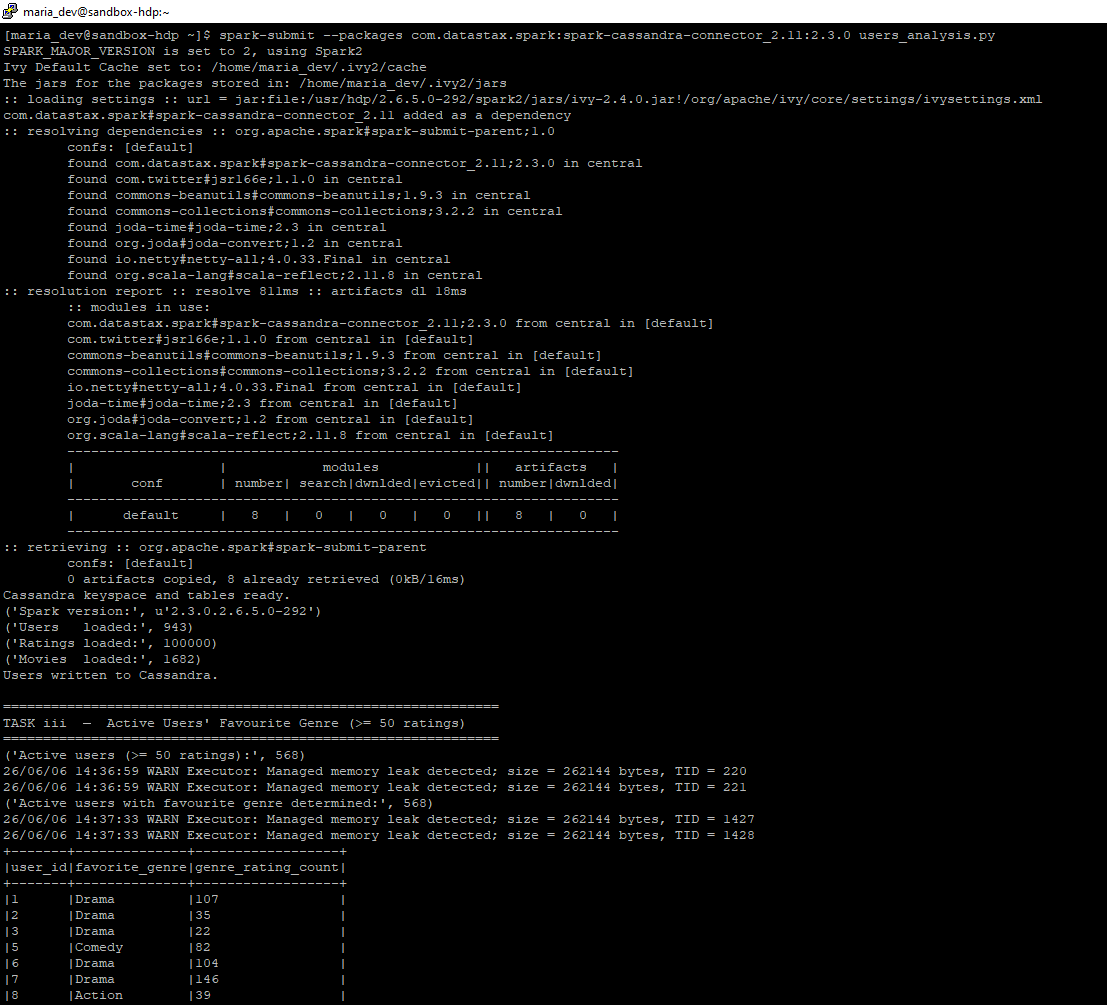

In [29]:
show_img('user_anaysis_output1.PNG')

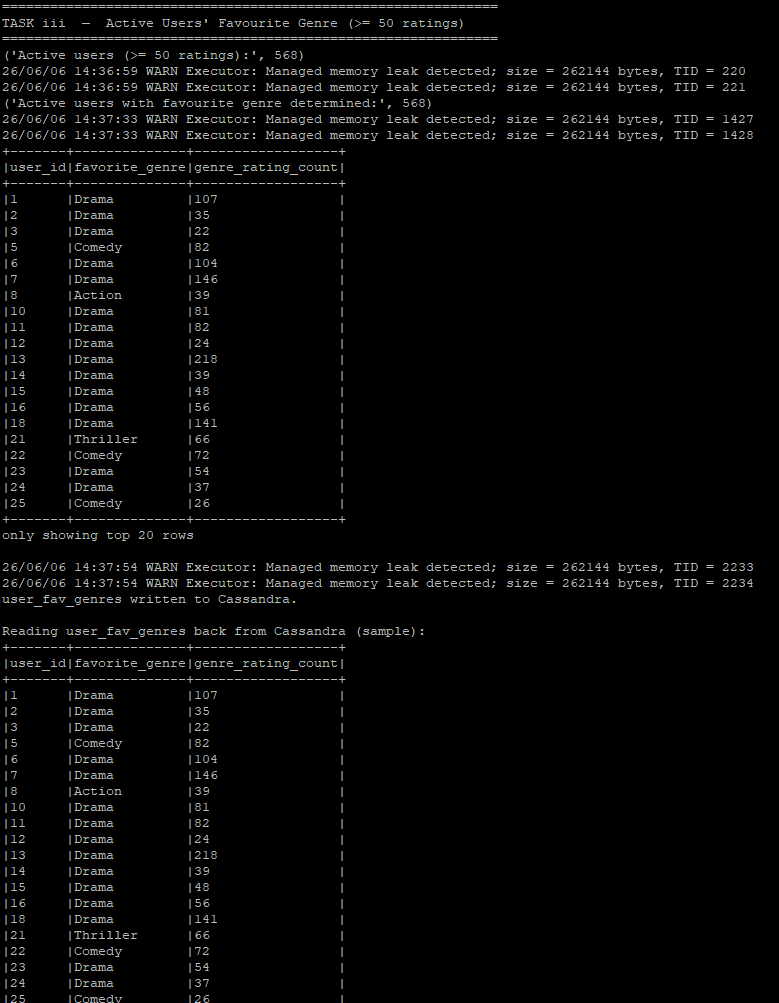

In [30]:
show_img('user_anaysis_output2.PNG')

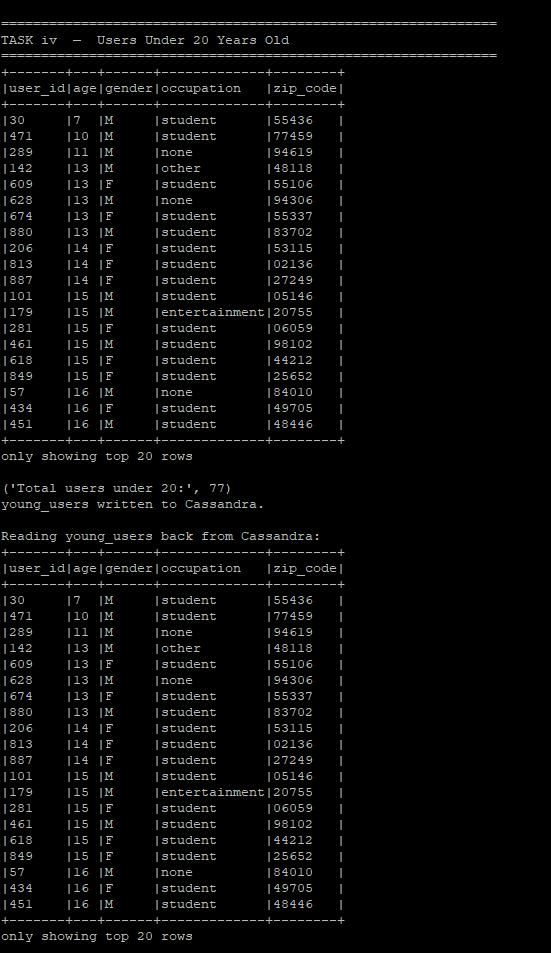

In [31]:
show_img('user_anaysis_output3.PNG')

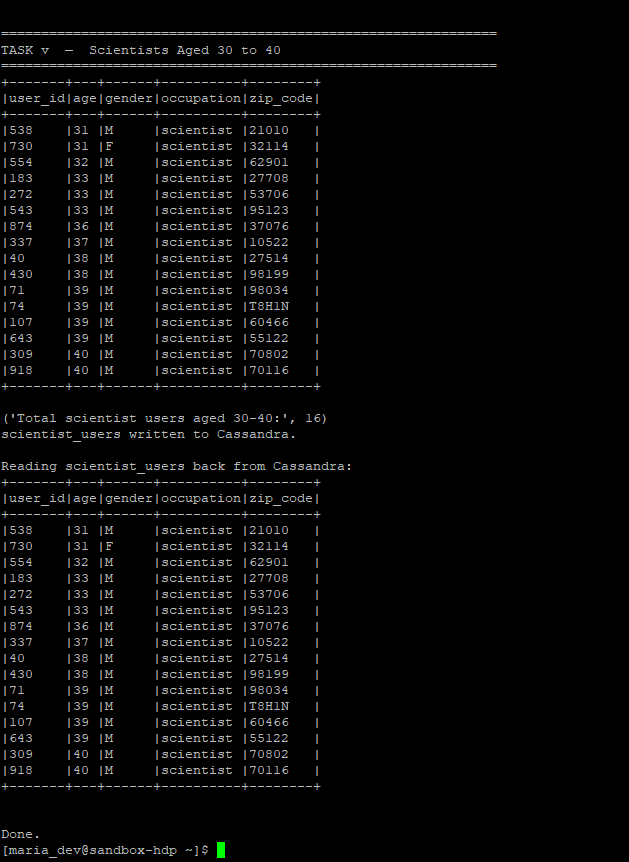

In [32]:
show_img('user_anaysis_output4.PNG')

---
### 2.7 Export Results from Cassandra to CSV using CQL commands

Once all results are stored in Cassandra, they are exported to CSV files using the
`COPY TO` command in `cqlsh`. This makes the data portable and we can also demonstrate a use case for the cassandra cql interface.The command actually saves the table from cassandra into local unix through putty. WinSCP was used to copy the csv file from the unix virtual machine to our windows machine. The outputs are then saved into cassandra_spark_outputs folder which is used in
this notebook for visualisation so that it does not need a live Cassandra connection. Below are the commands used for this action accompanied by a screenshot of its implementation in Putty.

```cql
USE movielens;
COPY avg_ratings     TO '/home/maria_dev/avg_ratings.csv'      WITH HEADER=TRUE;
COPY top_movies      TO '/home/maria_dev/top_movies.csv'       WITH HEADER=TRUE;
COPY user_fav_genres TO '/home/maria_dev/user_fav_genres.csv'  WITH HEADER=TRUE;
COPY young_users     TO '/home/maria_dev/young_users.csv'      WITH HEADER=TRUE;
COPY scientist_users TO '/home/maria_dev/scientist_users.csv'  WITH HEADER=TRUE;
```

The exported files are saved locally in `cassandra_spark_outputs/`.

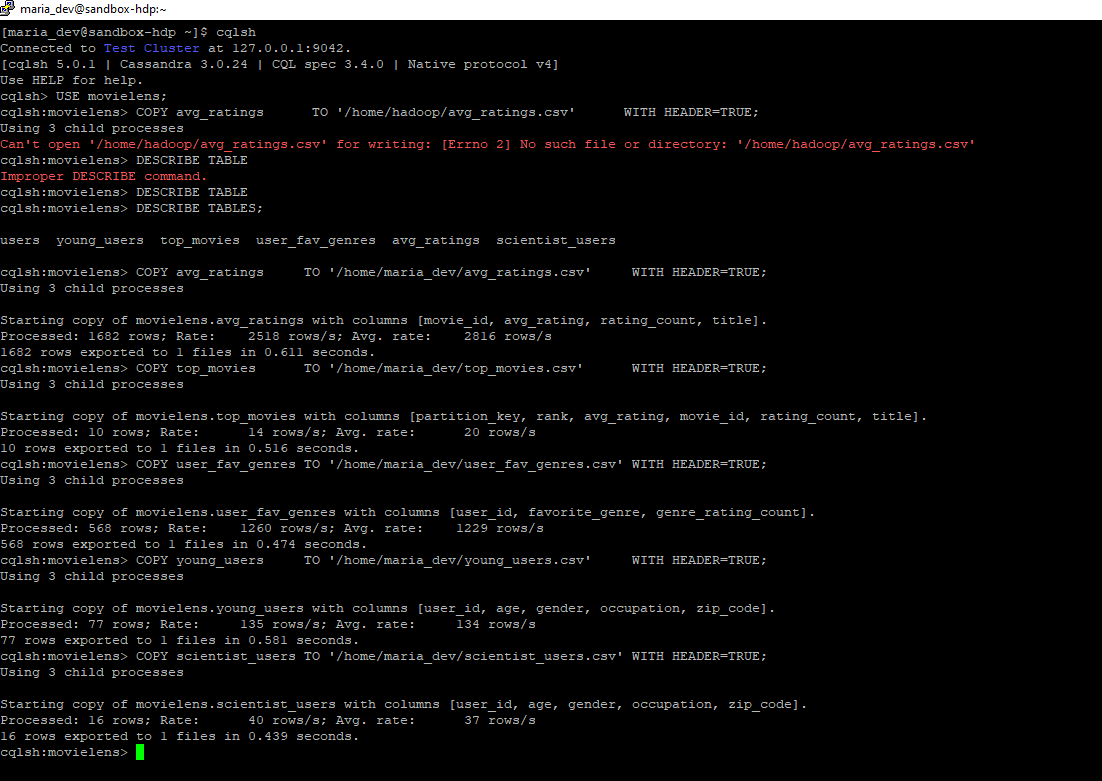

In [25]:
show_img('copy_data_to_putty.PNG')

---
## **3.0 Results and Discussion**
### 3.1 Results Summary

For each table in cassandra a corresponding csv file was exported and saved locally in this github repository. Below table presents the relationship of tables versus csv file and also presents the number of data in each data file.

| Task | Question | Output Table (Cassandra) | Output File | Records |
|:---:|---|---|---|---:|
| i | Average rating for each movie | `avg_ratings` | `avg_ratings.csv` | 1,682 |
| ii | Top 10 movies by average rating (min 10 ratings) | `top_movies` | `top_movies.csv` | 10 |
| iii | Active users (≥ 50 ratings) and their favourite genre | `user_fav_genres` | `user_fav_genres.csv` | 568 |
| iv | All users under 20 years old | `young_users` | `young_users.csv` | 77 |
| v | Scientists aged 30 to 40 | `scientist_users` | `scientist_users.csv` | 16 |

---
### 3.2 Visualisations

Next lets visualize the outputs so that we get a better understanding of the data that has been analyzed. The cells below load the exported CSV files and produce charts grouped around each task.

In [48]:
import os
import io
import urllib.request
import pandas as pd

local_dir = 'cassandra_spark_outputs'
github_base_url = 'https://raw.githubusercontent.com/muzaffarizamuddin/P166246_Assg2_STQD6324/main/cassandra_spark_outputs'

def load_csv_with_fallback(filename):
    """Loads a CSV from the local folder. If missing, downloads it directly from GitHub."""
    local_path = os.path.join(local_dir, filename)
    
    if os.path.exists(local_path):
        return pd.read_csv(local_path)
    
    print(f"Local file not found at '{local_path}'. Fetching from GitHub...")
    github_url = f"{github_base_url}/{filename}"
    
    try:
        with urllib.request.urlopen(github_url) as response:
            csv_data = response.read().decode('utf-8')
            return pd.read_csv(io.StringIO(csv_data))
    except Exception as e:
        print(f"Error: Could not retrieve '{filename}' locally or from GitHub.")
        print(f"Details: {e}")
        return None

avg_df = load_csv_with_fallback('avg_ratings.csv')
top_df = load_csv_with_fallback('top_movies.csv')
gen_df = load_csv_with_fallback('user_fav_genres.csv')
yng_df = load_csv_with_fallback('young_users.csv')
sci_df = load_csv_with_fallback('scientist_users.csv')

print('avg_ratings     :', len(avg_df) if avg_df is not None else 0, 'rows')
print('top_movies      :', len(top_df) if top_df is not None else 0, 'rows')
print('user_fav_genres :', len(gen_df) if gen_df is not None else 0, 'rows')
print('young_users     :', len(yng_df) if yng_df is not None else 0, 'rows')
print('scientist_users :', len(sci_df) if sci_df is not None else 0, 'rows')

avg_ratings     : 1682 rows
top_movies      : 10 rows
user_fav_genres : 568 rows
young_users     : 77 rows
scientist_users : 16 rows


---
#### 3.2.1 Average Rating for Each Movie (Output from Task 1)

Task 1 is a suitable start as it calculates the average rating for each movie. The average_rating.py script computed the average rating across all 1,682 movies. It would be good to understand the distribution of these average ratings and how do they relate to the number of reviews. We have already seen some movies can get rating 5 but only 1 person has reviewed the specific movie. Studying this output can tell us the relationship of number of reviews to the average rating score. To understand this further we utilize a histogram as well as a scatterplot. The charts below show how ratings are distributed and the relationship between how popular a movie is (number of ratings) and how well it is rated.

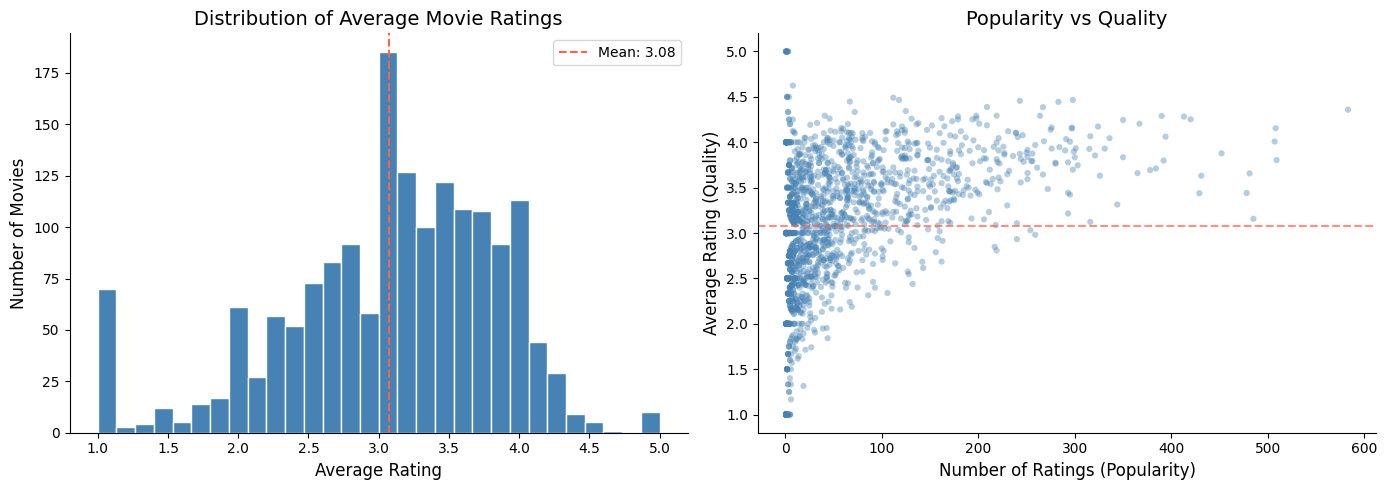

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Distribution of average ratings
axes[0].hist(avg_df['avg_rating'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Average Movie Ratings')
axes[0].set_xlabel('Average Rating')
axes[0].set_ylabel('Number of Movies')
axes[0].axvline(avg_df['avg_rating'].mean(), color='tomato', linestyle='--',
                label='Mean: {:.2f}'.format(avg_df['avg_rating'].mean()))
axes[0].legend()

# Chart 2: Rating count vs average rating (popularity vs quality)
axes[1].scatter(avg_df['rating_count'], avg_df['avg_rating'],
                alpha=0.4, color='steelblue', edgecolors='none', s=20)
axes[1].set_title('Popularity vs Quality')
axes[1].set_xlabel('Number of Ratings (Popularity)')
axes[1].set_ylabel('Average Rating (Quality)')
axes[1].axhline(avg_df['avg_rating'].mean(), color='tomato', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Interpretation:** Most movies cluster between ratings 3.0 and 4.0, with the mean sitting
around 3. The distribution is slightly left-skewed revealing that there are more poorly-rated movies
than excellent ones at the extremes. The scatter plot reveals a interesting pattern, movies with
very few ratings show high variance (a movie rated once can score 1 or 5), while popular movies with many ratings converge toward the 3.0–4.5 band. This is expected as humans have different tastes and average rating calculates the mean across everyone who has rated that movie.

---
### 3.2.2 Top 10 Movies by Average Rating (Outputs from Task 2)

From our finding above, 5 star rated movies with only 1 or 2 ratings submitted can be misleading. Therefore in this section lets filter and select movies with at least 10 ratings to removes flukes. Then this plot should highlight genuinely
well-regarded films. To do this we utilize a horizontal barchart that ranks the top 10 movies by average rating.

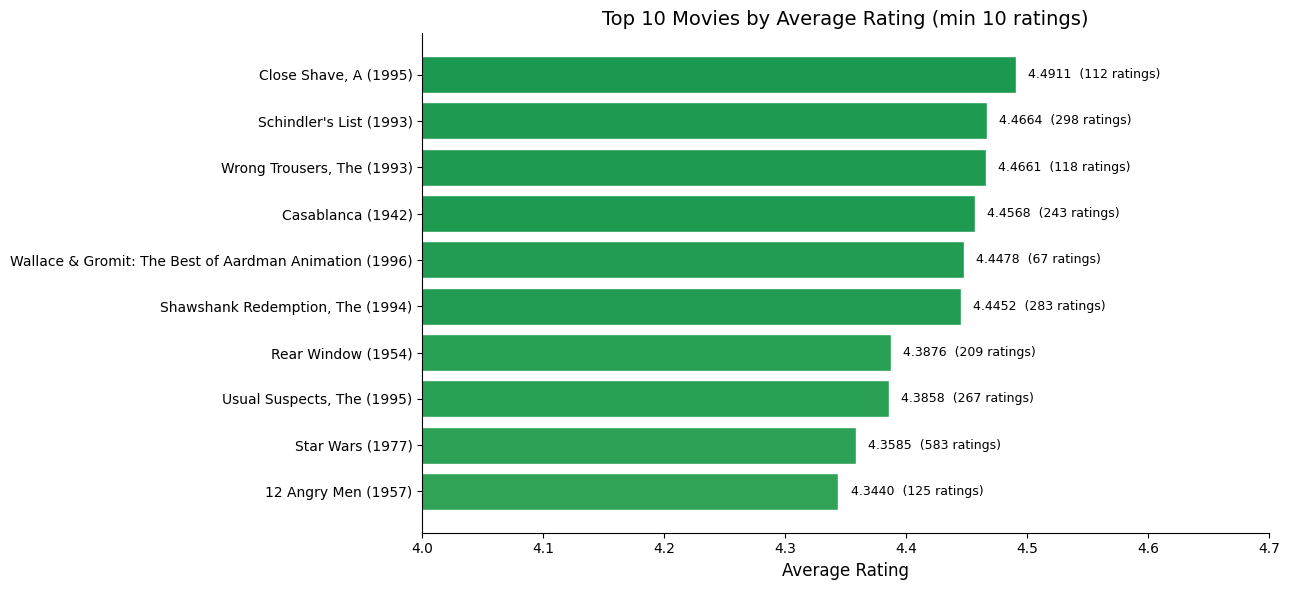

In [ ]:
top_sorted = top_df.sort_values('rank')

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(top_sorted['title'], top_sorted['avg_rating'],
               color=plt.cm.RdYlGn([x / 5 for x in top_sorted['avg_rating']]),
               edgecolor='white')

# Annotate with rating count
for bar, count, rating in zip(bars, top_sorted['rating_count'], top_sorted['avg_rating']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            '{:.4f}  ({} ratings)'.format(rating, count),
            va='center', fontsize=9)

ax.set_xlim(4.0, 4.7)
ax.invert_yaxis()
ax.set_title('Top 10 Movies by Average Rating (min 10 ratings)')
ax.set_xlabel('Average Rating')
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

plt.tight_layout()
plt.show()

**Interpretation:** The top spot goes to *A Close Shave (1995)* with an average rating of 4.49,
followed closely by *Schindler's List* and *The Wrong Trousers*. The list is dominated by
acclaimed dramas and critically-praised films from the 1990s. Notably, all ten movies sit
above 4.3 — a narrow band that highlights just how competitive the top tier is. There are some real classics within this top 10 including Star Wars, and the Shawshank Redemption.

---
### 3.2.3 Active Users' Favourite Genre (Outputs from Task iii)

From the dataset user_fav_genres.csv generated by the users_analysis.y script a total of 568 users was found to have rated at least 50 movies. This criteria that we have set should filter out the hardcore movie goers and movie critics as these are people who frequently drop reviews and love movies. It is important to understand what Genre do they focus on so that future movies can focus on those genres more exclusively. For the 568 users who rated at least 50 movies, we identified the genre they rated most frequently by using a vertical barchart and a piechart as conducted in below cell. Here, the number of reviews is used as a measure for favourite genre.

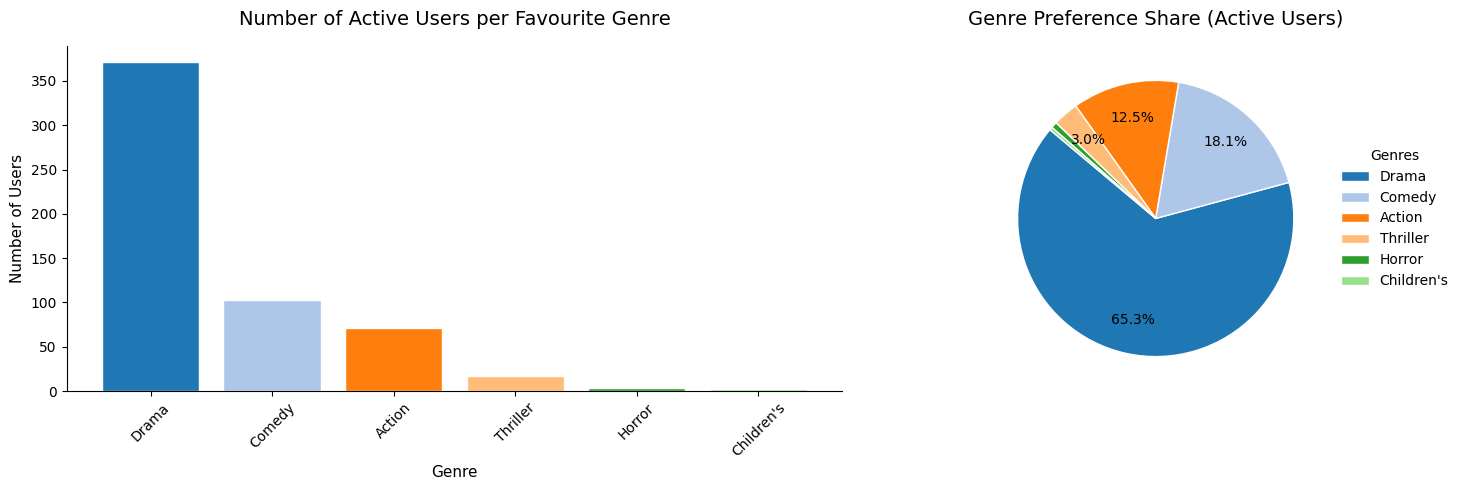


Top genres:
favorite_genre
Drama         371
Comedy        103
Action         71
Thriller       17
Horror          4
Children's      2


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Prepare data
genre_counts = gen_df['favorite_genre'].value_counts().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ----------------------------------------
# Chart 1: Bar chart (Unchanged)
# ----------------------------------------
colors = plt.cm.tab20.colors[:len(genre_counts)]
axes[0].bar(genre_counts.index, genre_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Number of Active Users per Favourite Genre', fontsize=14, pad=15)
axes[0].set_xlabel('Genre', fontsize=11)
axes[0].set_ylabel('Number of Users', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)

# Despine bar chart for a cleaner appearance
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)


# ----------------------------------------
# Chart 2: Cleaned Pie chart (Top 6 + Other)
# ----------------------------------------
top6 = genre_counts.head(6)
other = genre_counts.iloc[6:].sum()
pie_data = pd.concat([top6, pd.Series({'Other': other})])

# FIX 1: Filter out categories with 0 values to prevent 0.0% text overlaps
pie_data = pie_data[pie_data > 0]

# Setup colors so 'Other' always remains gray if it exists
pie_colors = list(plt.cm.tab20.colors[:len(pie_data)])
if 'Other' in pie_data.index:
    pie_colors[-1] = '#cccccc'

# FIX 2: Omit 'labels=pie_data.index' here to keep text outside of the pie geometry
wedges, texts, autotexts = axes[1].pie(
    pie_data.values, 
    autopct='%1.1f%%', 
    startangle=140,
    pctdistance=0.75,  # Better text positioning inside slices
    colors=pie_colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

# FIX 3: Hide tiny percentages (< 1%) that would otherwise overlap in small slices
for autotext in autotexts:
    if float(autotext.get_text().strip('%')) < 1.0:
        autotext.set_text('') 
    else:
        autotext.set_fontsize(10)
        autotext.set_color('black')

axes[1].set_title('Genre Preference Share (Active Users)', fontsize=14, pad=15)

# FIX 4: Add a clean side legend to safely host all the label names
axes[1].legend(
    wedges, 
    pie_data.index,
    title="Genres",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1), # Pushes the legend outside the subplot canvas
    frameon=False
)
plt.tight_layout()
plt.show()

print('\nTop genres:')
print(genre_counts.to_string())

**Interpretation:** Drama is by far the most popular genre among active users, followed by
Comedy and Action. This aligns with the broader MovieLens dataset, which skews heavily
toward drama and mainstream genres. Niche genres like Documentary and Film-Noir attract
very few users as a primary preference. Children movie genre are suprisingly very low in count. The next section will look deeper into this by filtering only under 20 years old users. 

---
### 3.2.4 Users Under 20 Years Old

After filtering the main dataset for those aged 20 and below, only 77 users was found in the dataset. This confirms why children movies were quite low in number when we plotted favourite user genres. Perhaps if we look into a dataset from Disney+ or nicklodeon the data would be more representative of the children's movie section. Nevertheless lets take a deeper look at our 77 under 20 users by understanding their age distribution, gender breakdown as well as the movies they love as represented by the average ratings by the users

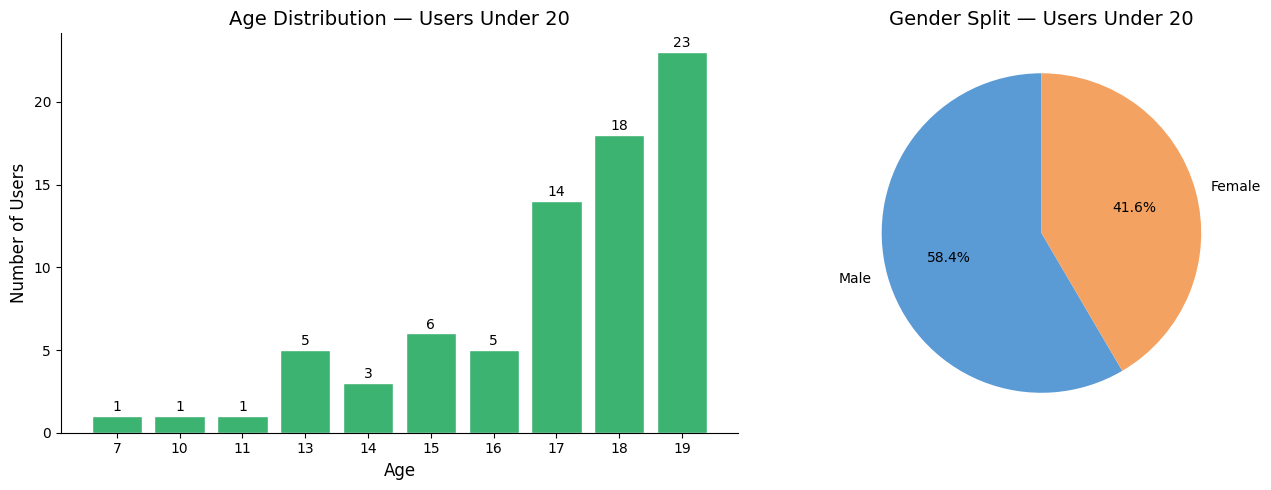

Total users under 20: 77
Gender breakdown:
gender
M    45
F    32


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Age distribution
age_counts = yng_df['age'].value_counts().sort_index()
axes[0].bar(age_counts.index.astype(str), age_counts.values,
            color='mediumseagreen', edgecolor='white')
axes[0].set_title('Age Distribution — Users Under 20')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Users')
for i, v in enumerate(age_counts.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontsize=10)

# Chart 2: Gender breakdown
gender_counts = yng_df['gender'].value_counts()
axes[1].pie(gender_counts.values,
            labels=['Male' if g == 'M' else 'Female' for g in gender_counts.index],
            autopct='%1.1f%%', startangle=90,
            colors=['#5b9bd5', '#f4a261'])
axes[1].set_title('Gender Split — Users Under 20')

plt.tight_layout()
plt.show()

print('Total users under 20:', len(yng_df))
print('Gender breakdown:')
print(gender_counts.to_string())

**Interpretation:** Teenagers aged 17–19 make up the majority of under-20 users,
with 19-year-olds being the most represented age at 23 persons. The gender split shows the dataset's
broader trend of slightly more male than female raters, which would undoubtedly effect the movie preference and choices. 

#### What Movies Do Users Under 20 Rate Highly?

Beyond demographics, it is interesting to see which films this age group actually enjoyed. To do this we may need to access the raw u.data and u.item dataset as our spark script data did not save the relevant info for us to do this analysis.
The chart below shows the top-rated movies among under-20 users. A minimum number of 5 reviews were set as a filter to ensure a fair average rating was used to compare against each other. 

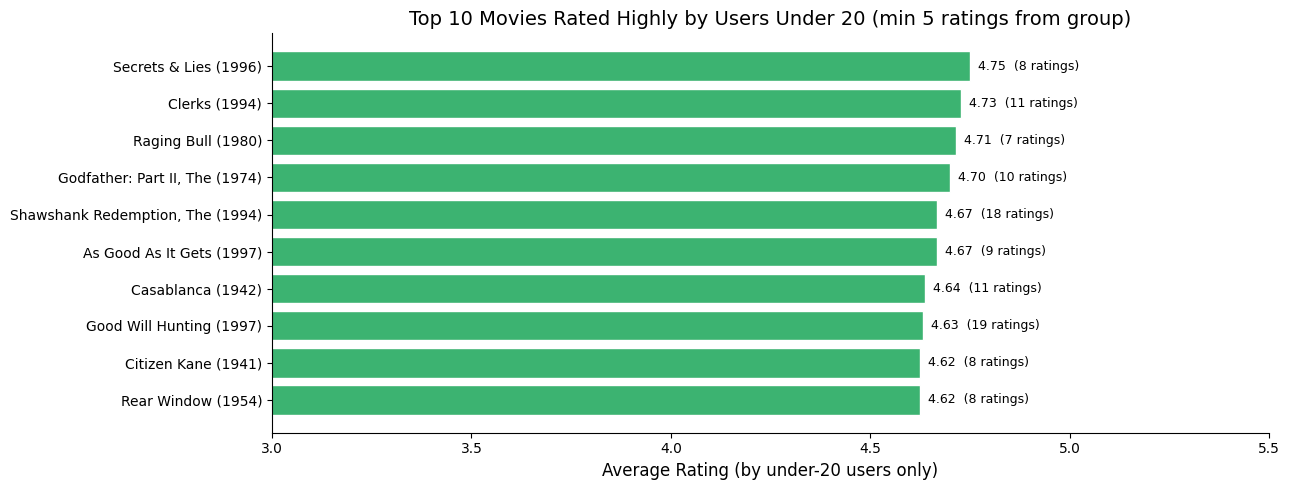

In [53]:
import os
import io
import urllib.request
import pandas as pd
import matplotlib.pyplot as plt

# Define local folder and GitHub base url for the dataset
local_dataset_dir = 'ml-100k'
github_dataset_url = 'https://raw.githubusercontent.com/muzaffarizamuddin/P166246_Assg2_STQD6324/main/ml-100k'

def load_dataset_csv_with_fallback(filename, **kwargs):
    """Loads a raw dataset file locally, or falls back to downloading it from GitHub."""
    local_path = os.path.join(local_dataset_dir, filename)
    
    if os.path.exists(local_path):
        return pd.read_csv(local_path, **kwargs)
    
    print(f"Local file not found at '{local_path}'. Fetching from GitHub...")
    github_url = f"{github_dataset_url}/{filename}"
    
    try:
        with urllib.request.urlopen(github_url) as response:
            encoding = kwargs.get('encoding', 'utf-8')
            raw_data = response.read().decode(encoding)
            return pd.read_csv(io.StringIO(raw_data), **kwargs)
    except Exception as e:
        print(f"Error: Could not retrieve '{filename}' locally or from GitHub.")
        print(f"Details: {e}")
        return None

u_ratings = load_dataset_csv_with_fallback('u.data', sep='\t',
                                           names=['user_id', 'movie_id', 'rating', 'timestamp'])

u_movies  = load_dataset_csv_with_fallback('u.item', sep='|', encoding='latin-1',
                                           usecols=[0, 1], names=['movie_id', 'title'])

# Filter to ratings made by under-20 users only
young_ids   = set(yng_df['user_id'])
young_rated = (u_ratings[u_ratings['user_id'].isin(young_ids)]
               .groupby('movie_id')
               .agg(avg_rating=('rating', 'mean'), num_ratings=('rating', 'count'))
               .reset_index()
               .query('num_ratings >= 5')
               .merge(u_movies, on='movie_id')
               .sort_values('avg_rating', ascending=False)
               .head(10))

# Plotting
fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.barh(young_rated['title'], young_rated['avg_rating'],
               color='mediumseagreen', edgecolor='white')

for bar, cnt, rat in zip(bars, young_rated['num_ratings'], young_rated['avg_rating']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
            '{:.2f}  ({} ratings)'.format(rat, cnt),
            va='center', fontsize=9)

ax.set_xlim(3.0, 5.5)
ax.invert_yaxis()
ax.set_title('Top 10 Movies Rated Highly by Users Under 20 (min 5 ratings from group)')
ax.set_xlabel('Average Rating (by under-20 users only)')
plt.tight_layout()
plt.show()

**Interpretation:** Its interesting to see the movies that these young movie goers are highly rating. Movies like Casablanca and Citizen Kane are actually black and white movies. I think these observation just reflects the age of the movielens 100k dataset and the same analysis on netflix data would most likely show more recent animation movies for similar age range. That being said movies like Shawshank redemption and Good will hunting could be deeply relatable to them with storylines that emphasizes identity struggle and figuring out life. 

---
### 3.2.5 Scientists Aged 30 to 40

Now we are looking at an even smaller group due to the heavy filtering of both occupation and age. Only 16 users identify as scientists and fall within the 30–40 age bracket. Despite being a small group, they form an interesting demographic segment that can represent a large number of people in the real world. As a demonstration, this notebook will plot the visualization of this dataset.

#### What Movies Do Scientists (30–40) Rate Highly?

With only 16 users in this group the threshold for minimum number of ratings is lowered to 3 to produce a
meaningful list. The chart reveals the film tastes of a scientific nature.

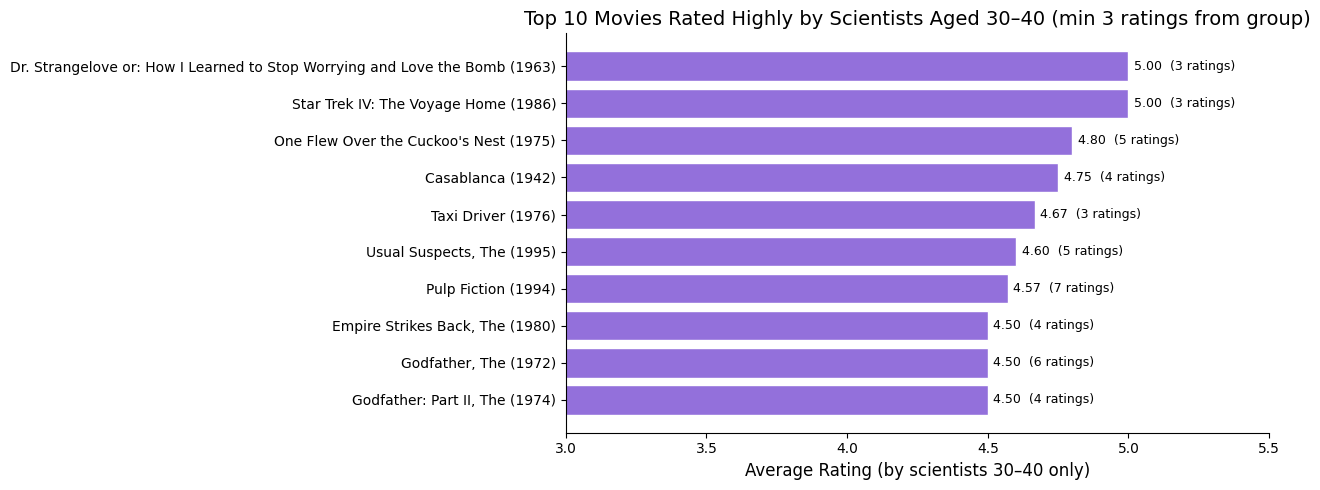

In [ ]:
# Filter to ratings made by scientists aged 30-40
# u_ratings and u_movies were loaded in the Task iv cell above
sci_ids   = set(sci_df['user_id'])
sci_rated = (u_ratings[u_ratings['user_id'].isin(sci_ids)]
             .groupby('movie_id')
             .agg(avg_rating=('rating', 'mean'), num_ratings=('rating', 'count'))
             .reset_index()
             .query('num_ratings >= 3')
             .merge(u_movies, on='movie_id')
             .sort_values('avg_rating', ascending=False)
             .head(10))

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.barh(sci_rated['title'], sci_rated['avg_rating'],
               color='mediumpurple', edgecolor='white')
for bar, cnt, rat in zip(bars, sci_rated['num_ratings'], sci_rated['avg_rating']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
            '{:.2f}  ({} ratings)'.format(rat, cnt),
            va='center', fontsize=9)
ax.set_xlim(3.0, 5.5)
ax.invert_yaxis()
ax.set_title('Top 10 Movies Rated Highly by Scientists Aged 30–40 (min 3 ratings from group)')
ax.set_xlabel('Average Rating (by scientists 30–40 only)')
plt.tight_layout()
plt.show()

**Interpretation:** From the horizontal barchart above we can see that the movies preferred by scientist at the age range of 30 to 40 are highly related to science in some ways. The first thing we can see is a the number of science fiction movies represented by the movie Star Trek and Star Wars (Empire Strikes Back). Masterpieces like The Usual Suspects, Pulp Fiction and The Godfather have complex narratives requiring the viewer to map out timelines and cause-and-effect which could be why these films resonate with this group of viewers.

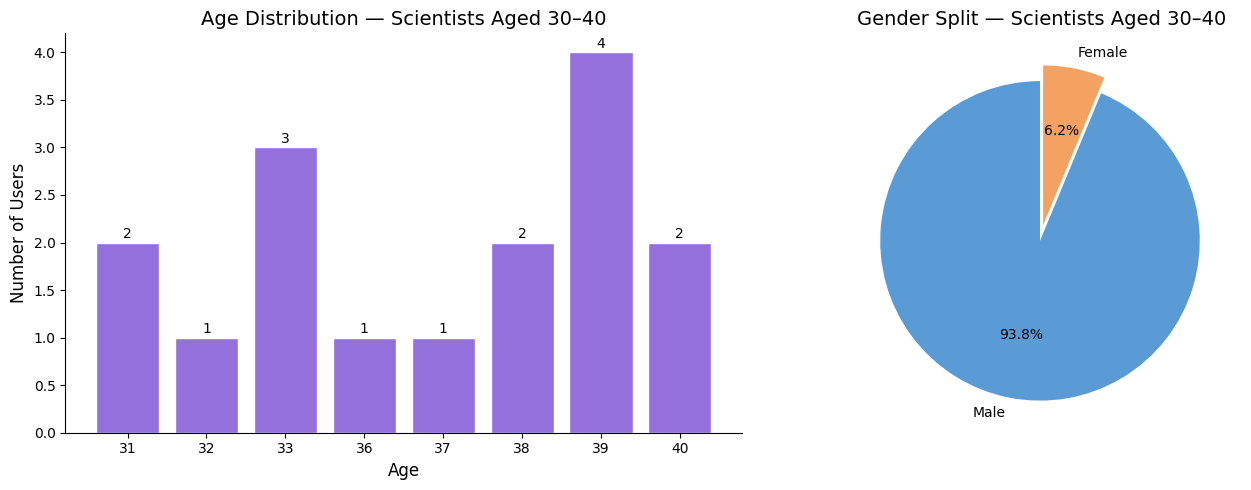

Total scientist users aged 30-40: 16
 user_id  age gender
     538   31      M
     730   31      F
     554   32      M
     272   33      M
     543   33      M
     183   33      M
     874   36      M
     337   37      M
     430   38      M
      40   38      M
     643   39      M
      71   39      M
     107   39      M
      74   39      M
     918   40      M
     309   40      M


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Age distribution of scientists
sci_age = sci_df['age'].value_counts().sort_index()
axes[0].bar(sci_age.index.astype(str), sci_age.values,
            color='mediumpurple', edgecolor='white')
axes[0].set_title('Age Distribution — Scientists Aged 30–40')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Users')
for i, v in enumerate(sci_age.values):
    axes[0].text(i, v + 0.05, str(v), ha='center', fontsize=10)

# Chart 2: Gender breakdown
sci_gender = sci_df['gender'].value_counts()
axes[1].pie(sci_gender.values,
            labels=['Male' if g == 'M' else 'Female' for g in sci_gender.index],
            autopct='%1.1f%%', startangle=90,
            colors=['#5b9bd5', '#f4a261'],
            explode=[0.05] * len(sci_gender))
axes[1].set_title('Gender Split — Scientists Aged 30–40')

plt.tight_layout()
plt.show()

print('Total scientist users aged 30-40:', len(sci_df))
print(sci_df[['user_id', 'age', 'gender']].sort_values('age').to_string(index=False))

**Interpretation:** Scientists in this dataset are predominantly male, which reflects
the gender imbalance in STEM fields during the late 1990s (when the data was collected). We believe the number of females in this field would have increase if taking a more recent data. On the other hand, age is spread fairly evenly across the 30–40 range with no strong concentration at a particular age. With only 16 users this is a small group but it is a useful demonstration
of combining occupation and age filters in a single Cassandra query. The dataset also provides some understanding of what movies are preferred by scientist in this age group.


## **4.0 HBase : Recommended movies per customer**
An additional HBase-based recommendation engine was implemented in the script named `hbase/hbase_analysis.py`. Using Spark, each user's favourite genre was identified and the top-5 unrated movies in that genre were computed. These recommendations were stored into HBase using a wide-column model (one row per user, multiple columns per recommendation rank). The idea is to demonstrate HBase's suitability for fast lookups as a contrast to Cassandra's CQL approach. The Spark computed recommendation data was executed, thus storing the output into Hbase. At the same time the output is also stored locally at `hbase/recommendations.csv` for reproducability. The csv output matching the Hbase database contains 4,715 rows, which is made up of 5 recommendations per user across 944 users. The putty outputs from the hbase_analysis.py execution is dhown below.

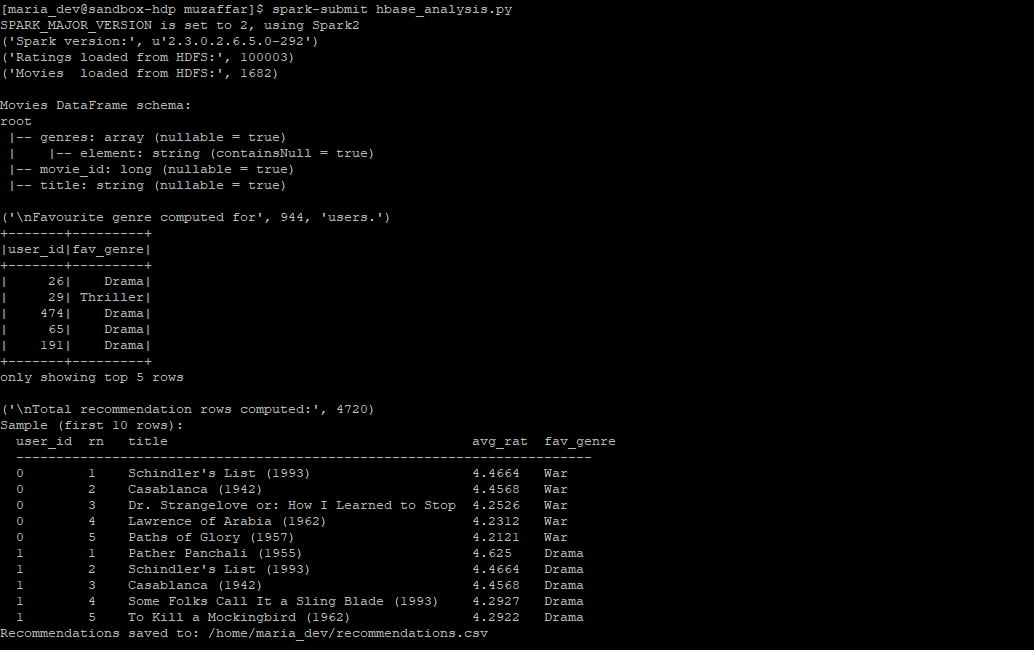

In [35]:
show_img('hbase_lab_1.png')

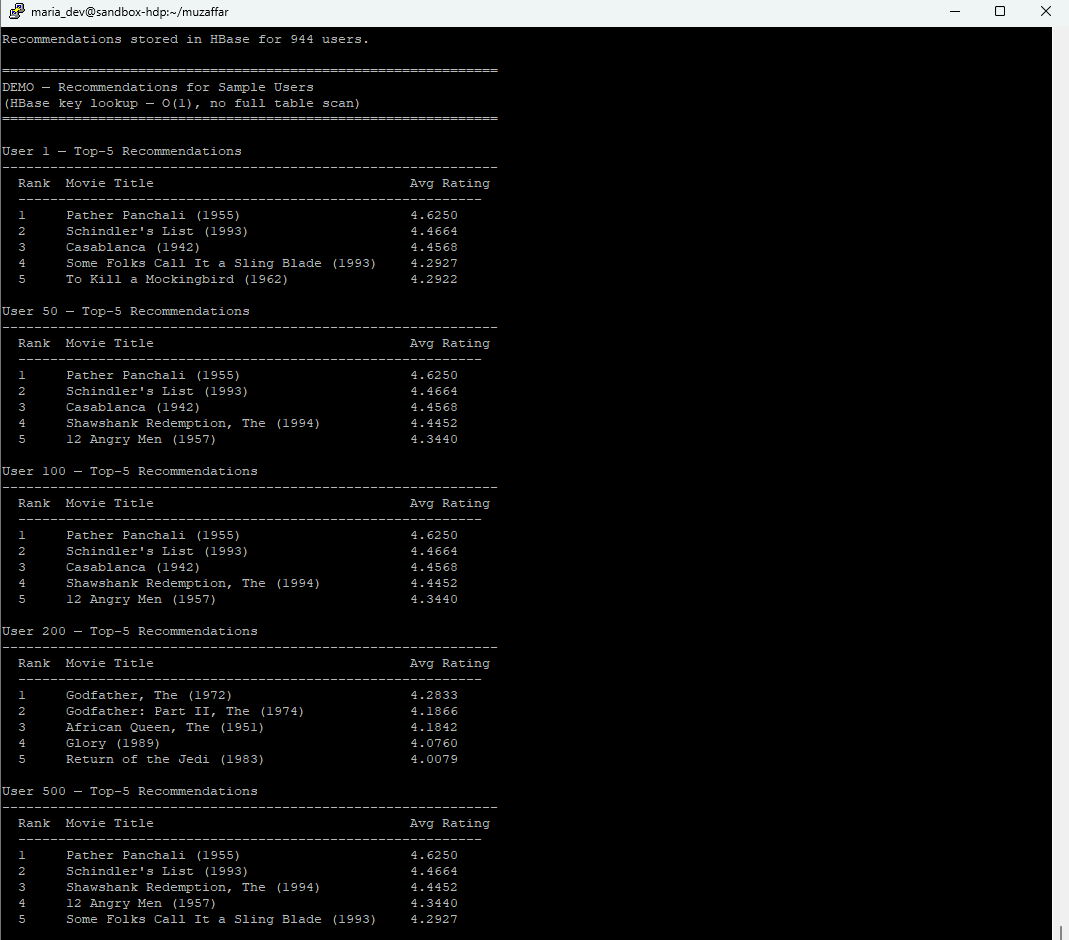

In [ ]:
show_img('hbase_lab_3.png')

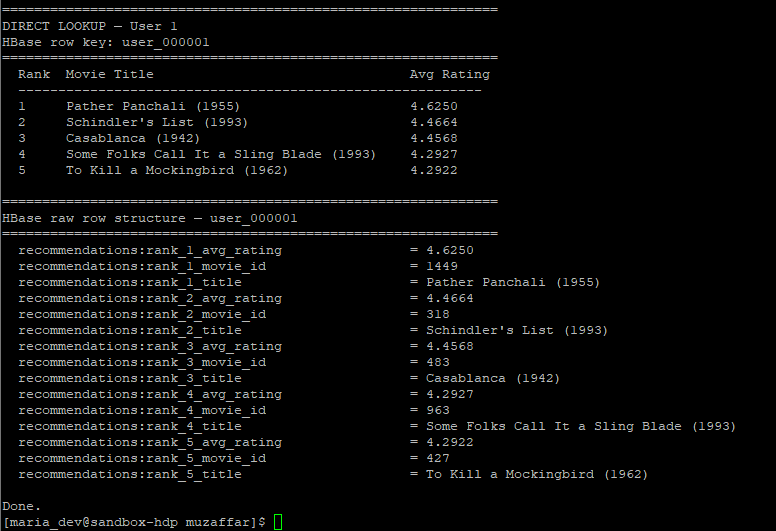

In [ ]:
show_img('hbase_lab_4.png')

### 4.1 Using Hbase manually (Hbase Shell)

After executing the script, we then utilize Putty to manually call the movielens_recommendations table that was created automatically by the hbase_analysis.py script. The command get was used to get specific recommendations per user. User 1 is denoted by user_000001 while User 50 is denoted by user_000050. 

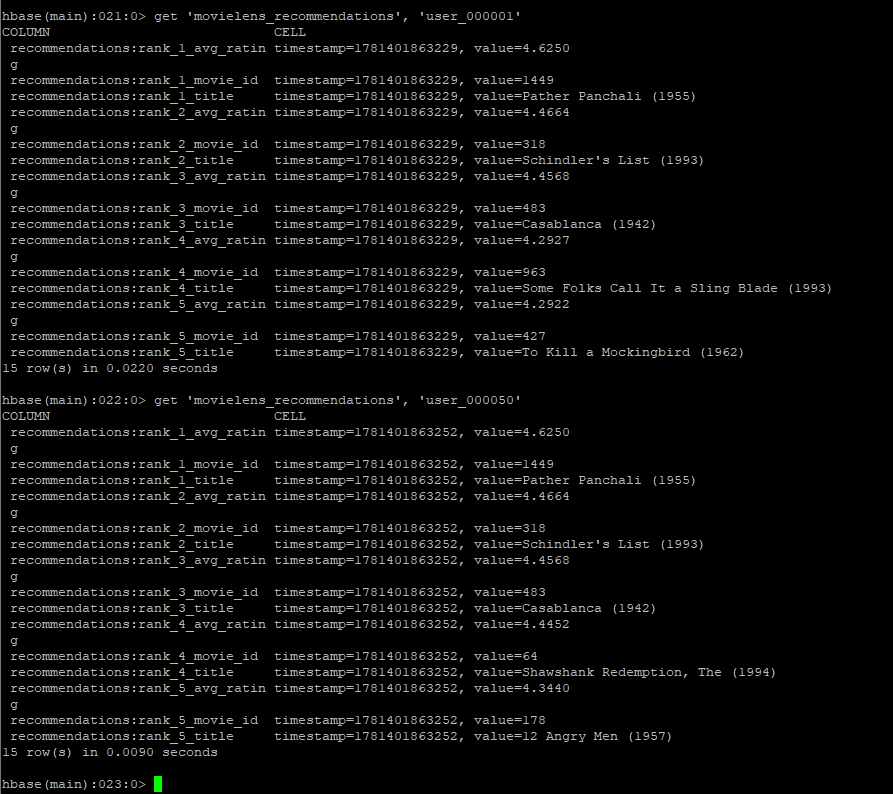

In [ ]:
show_img('hbase_manual_1_and_50.png')

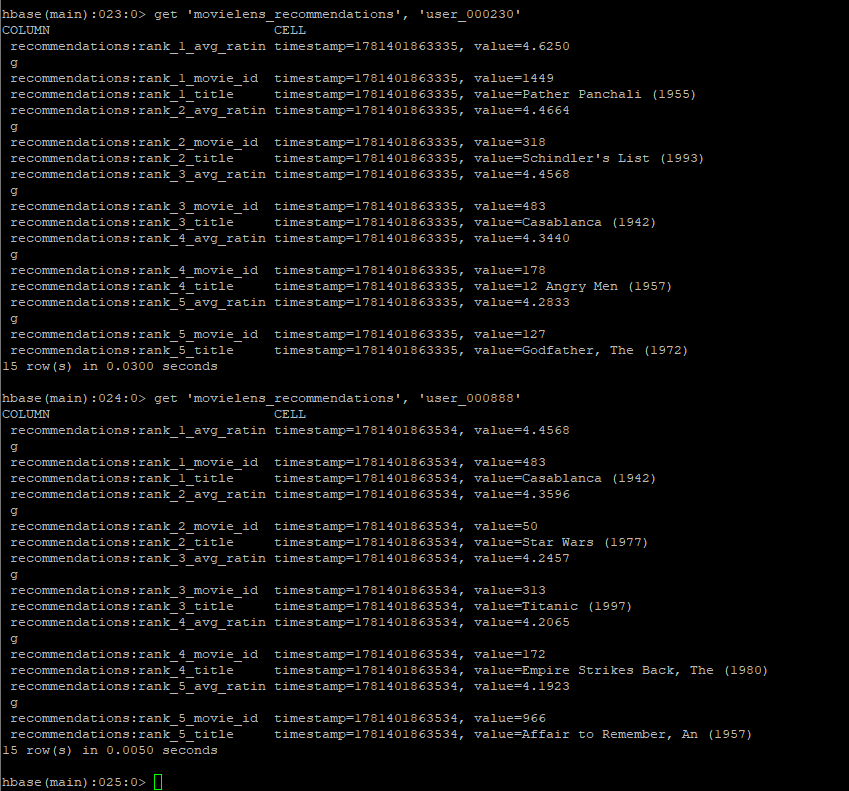

In [ ]:
show_img('hbase_manual_230_and_888.png')

### 4.2 Utilizing Hbase database via REST API to connect to Jupyter notebook

To demonstrate that Hbase can be used across platform through port forwarding, the Hbase database is then integrated into this python code. By utilizing REST API, and running jupyter notebook alongside HDP 2.6.5, we were able to call below function to query directly from Hbase

As an alternative, as this file may need to be run on colab without a hadoop system running in parallel, we also add a fallback for downloading recommendations.csv from github and reading the results locally from this csv file. 

In [ ]:
!pip install starbase #for colab

In [22]:
import os
import pandas as pd
from starbase import Connection

# =========================================================================
# CONFIGURATION
# =========================================================================
TABLE_NAME = 'movielens_recommendations'
LOCAL_CSV_PATH = os.path.join('hbase', 'recommendations.csv')
GITHUB_RAW_URL = "https://raw.githubusercontent.com/muzaffarizamuddin/P166246_Assg2_STQD6324/main/hbase/recommendations.csv"

# =========================================================================
# UNIVERSAL LOOKUP FUNCTION WITH TIMEOUT
# =========================================================================
def get_recommendations(user_input):
    """
    Fetches movie recommendations for an assignment grading environment.
    Prioritizes Live HBase REST -> Falls back to Local CSV -> Falls back to GitHub Raw CSV.
    Accepts a single user ID integer or a list of user ID integers.
    """
    user_ids = user_input if isinstance(user_input, list) else [user_input]
    
    # ---------------------------------------------------------------------
    # MODE 1: TRY LIVE HBASE REST API WITH STRICT TIMEOUTS
    # ---------------------------------------------------------------------
    try:
        # Enforcing a strict 1-second connect timeout via the internal connection dictionary.
        # This completely stops the notebook cell from hanging indefinitely.
        c = Connection(host="127.0.0.1", port="8000")
        
        # Override connection pool settings to fail fast
        c.client.session.get_adapter('http://').poolmanager.connection_pool_kw['timeout'] = 1.0
        c.client.session.get_adapter('https://').poolmanager.connection_pool_kw['timeout'] = 1.0
        
        table = c.table(TABLE_NAME)
        
        # Verify connectivity using an explicit quick check
        if table.exists():
            print(">>> Strategy: Connected successfully to Live HBase REST Gateway.")
            for user_id in user_ids:
                row_key = "user_{:06d}".format(user_id)
                print_header(user_id, "HBASE LIVE DB", row_key)
                
                row_data = table.fetch(row_key)
                if not row_data:
                    print("  No recommendation profile found in HBase for row key: {}".format(row_key))
                else:
                    recommendations = row_data.get('recommendations', {})
                    print_table_rows_from_dict(recommendations)
                print("=" * 65 + "\n")
            return  # Exit function cleanly if live path succeeds
            
    except Exception:
        # Silently catch the connection or timeout error to instantly jump to fallbacks
        pass

    # ---------------------------------------------------------------------
    # MODE 2 & 3: STATIC FILE FALLBACKS (Cluster Offline/Suspended)
    # ---------------------------------------------------------------------
    df = None
    
    # Check Local Directory first
    if os.path.exists(LOCAL_CSV_PATH):
        print(">>> Source: HBase cluster offline. Loading from local file: {}".format(LOCAL_CSV_PATH))
        df = pd.read_csv(LOCAL_CSV_PATH)
    else:
        # Download straight from GitHub repo if missing locally
        print(">>> Source: Local file missing. Downloading fallback dataset from GitHub...")
        try:
            df = pd.read_csv(GITHUB_RAW_URL)
        except Exception as csv_err:
            print("Error: Could not retrieve backup data locally or via GitHub network. Check internet connection.")
            return

    # Process dataset rows if loaded via file strategies
    if df is not None:
        for user_id in user_ids:
            user_recs = df[df['user_id'] == user_id].sort_values(by='rank')
            
            print_header(user_id, "FALLBACK STATIC DATASET")
            if user_recs.empty:
                print("  No recommendation profile found for user_id: {}".format(user_id))
            else:
                print("  {:<5} {:<10} {:<42} {}".format("Rank", "Movie ID", "Movie Title", "Avg Rating"))
                print("  " + "-" * 61)
                for _, row in user_recs.iterrows():
                    print("  {:<5} {:<10} {:<42} {}".format(
                        int(row['rank']), int(row['movie_id']), str(row['title'])[:41], row['avg_rating']
                    ))
            print("=" * 65 + "\n")

# =========================================================================
# DISPLAY FORMATTING HELPERS
# =========================================================================
def print_header(user_id, strategy_name, row_key=None):
    print("=" * 65)
    print("RECOMMENDATION LOOKUP ({}) — User {}".format(strategy_name, user_id))
    if row_key:
        print("HBase Row Key: {}".format(row_key))
    print("=" * 65)

def print_table_rows_from_dict(recommendations):
    print("  {:<5} {:<10} {:<42} {}".format("Rank", "Movie ID", "Movie Title", "Avg Rating"))
    print("  " + "-" * 61)
    for rank in range(1, 6):
        title = recommendations.get('rank_{}_title'.format(rank), "Unknown Title")
        m_id  = recommendations.get('rank_{}_movie_id'.format(rank), "N/A")
        rate  = recommendations.get('rank_{}_avg_rating'.format(rank), "N/A")
        print("  {:<5} {:<10} {:<42} {}".format(rank, m_id, title[:41], rate))

print("Universal function 'get_recommendations' ready with connection armor!")

Universal function 'get_recommendations' ready with connection armor!


In [23]:
get_recommendations([50])

>>> Source: HBase cluster offline. Loading from local file: hbase\recommendations.csv
RECOMMENDATION LOOKUP (FALLBACK STATIC DATASET) — User 50
  Rank  Movie ID   Movie Title                                Avg Rating
  -------------------------------------------------------------
  1     1449       Pather Panchali (1955)                     4.625
  2     318        Schindler's List (1993)                    4.4664
  3     483        Casablanca (1942)                          4.4568
  4     64         Shawshank Redemption, The (1994)           4.4452
  5     178        12 Angry Men (1957)                        4.344



In [24]:
get_recommendations([1]) 

>>> Source: HBase cluster offline. Loading from local file: hbase\recommendations.csv
RECOMMENDATION LOOKUP (FALLBACK STATIC DATASET) — User 1
  Rank  Movie ID   Movie Title                                Avg Rating
  -------------------------------------------------------------
  1     1449       Pather Panchali (1955)                     4.625
  2     318        Schindler's List (1993)                    4.4664
  3     483        Casablanca (1942)                          4.4568
  4     963        Some Folks Call It a Sling Blade (1993)    4.2927
  5     427        To Kill a Mockingbird (1962)               4.2922



In [25]:
get_recommendations([943])

>>> Source: HBase cluster offline. Loading from local file: hbase\recommendations.csv
RECOMMENDATION LOOKUP (FALLBACK STATIC DATASET) — User 943
  Rank  Movie ID   Movie Title                                Avg Rating
  -------------------------------------------------------------
  1     313        Titanic (1997)                             4.2457
  2     515        Boot, Das (1981)                           4.204
  3     498        African Queen, The (1951)                  4.1842
  4     651        Glory (1989)                               4.076
  5     183        Alien (1979)                               4.0344



As we can see from the outputs, user 1 , 50 and 943 all have different movie recommended for their viewing. It is important to note that the recommender system only looks at the Genre and then based on the best rated movies in that genre a recommendation is made. This might not be the best model to recommend movies Genre's are a large class of movies. For future implementation, perhaps a recommender system should use more inputs including Year released (to denote recentness) and age group on top of the Genre and ratings we have implemented here.

## **5.0 MongoDB : Least Liked Movies per user**

In this section we aim to write a python spark program that finds the least liked movie per customer and then utilize MongoDB to perform fast output from mongo based queries. The mongoDB is used within Putty, then a copy of the database is saved into github for reproducability. Firstly, the script mongodb_analysis.py is created in Putty using vi command. This script calculates the least like movies per user then stores the data into mongo database. After running this script, we should be able to use mongo database natively inside Putty. After the creation of the script, spark-submit was utilized to run the script as the initial calculation part of the script uses spark. 

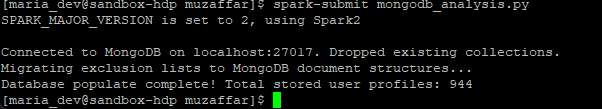

In [ ]:
show_img('mongodb_1.png')

After the database has been created, we log into mongo through Putty to check the outputs. The command use movielens_exclusion_db is used to switch to the right database, then using the command db.least_liked_movies.find and passing user_id as inputs, the outputs of the mongo database is displayed in a structured json output. Movies Free Willy is the least liked movie for user 1 and should not be in the suggestion list of next movies to watch.

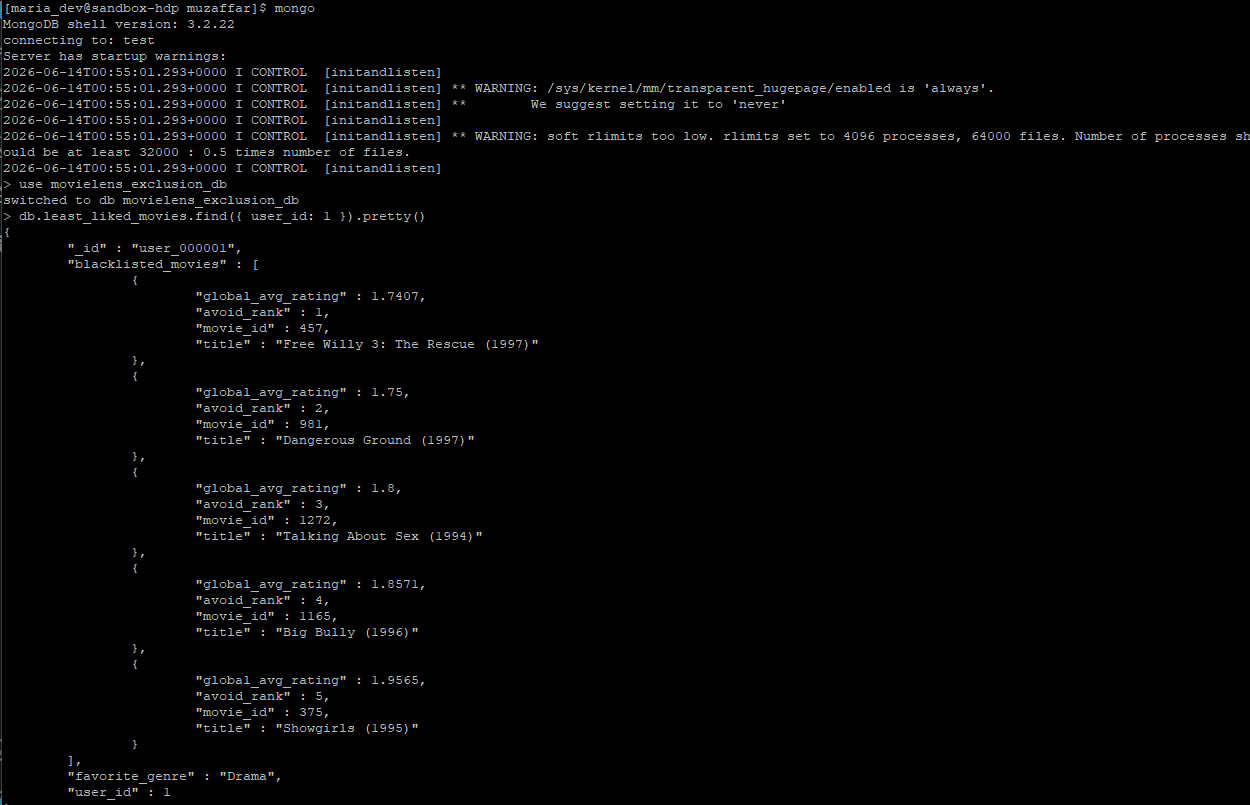

In [ ]:
show_img('mongodb_2.png')

We can perform this query for any user. An example for user 50 is as shown below.

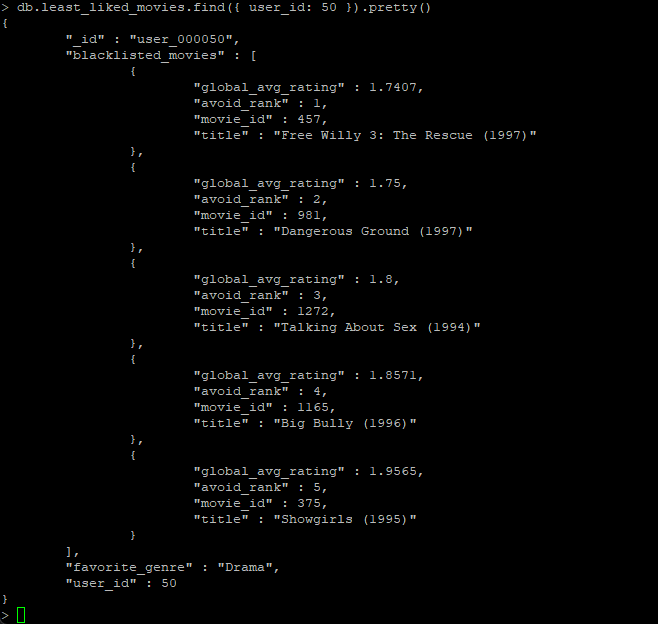

In [ ]:
show_img('mongodb_3.png')

We could also use aggregation to find the univerally least liked movie of all time based on this database. We gound that Free Willy 3 and Dangerous Ground (1997) are two movies which people universally liked least.

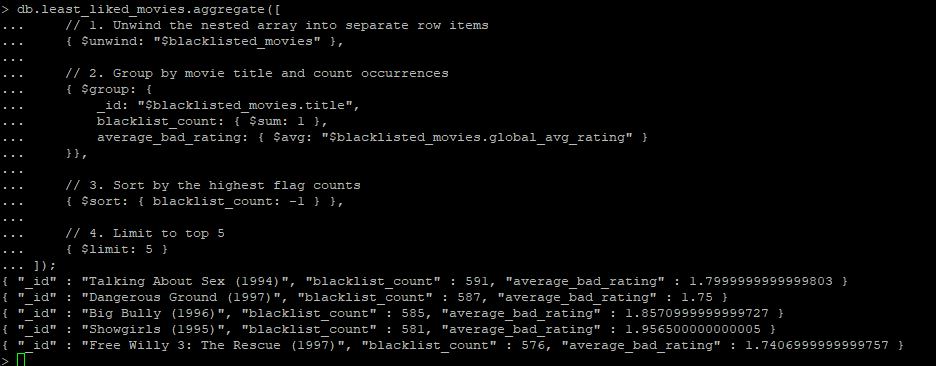

In [ ]:
show_img('mongodb_3_universally_disliked.png')

Finally, we export the mongo database into a csv file by using export_exclusions.py script. This script can be run without spark-submit as all the script does is read the 5 movies and structure into a csv exportable format.

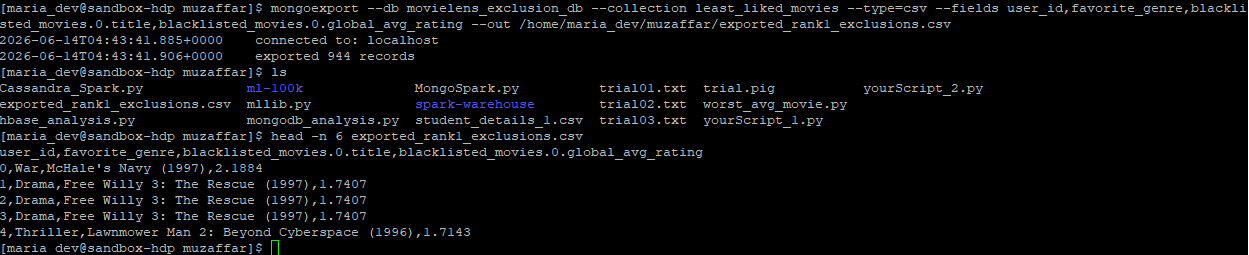

In [ ]:
show_img('mongodb_4_export.png')

Next, the exported movielens_exclusion_db database can be copied directly to windows via WinSCP app. A copy of the exported file is also saved into github to allow reproducability in Colab without an attach Hadoop cluster. The function below prioritizes reading from a REST API, but has a fallback to load from github in the case of an unreachable API.

In [30]:
import os
import pandas as pd

# =========================================================================
# CONFIGURATION - MULTI-ROW FALLBACK TARGETS
# =========================================================================
LOCAL_CSV_PATH = "mongo/exported_all_exclusions.csv"
GITHUB_RAW_URL = "https://raw.githubusercontent.com/muzaffarizamuddin/P166246_Assg2_STQD6324/main/mongo/exported_all_exclusions.csv"
# =========================================================================
# MONGODB ASSIGNMENT EXCLUSION LOOKUP
# =========================================================================
def get_mongo_exclusions(user_input):
    """
    Queries UI exclusions using the completely flattened multi-row processed dataset snapshot.
    """
    user_ids = user_input if isinstance(user_input, list) else [user_input]
    df = None
    
    # Strategy 1: Check Local Workspace
    if os.path.exists(LOCAL_CSV_PATH):
        print(">>> Strategy: Loading comprehensive exclusion footprints from local workspace: {}".format(LOCAL_CSV_PATH))
        df = pd.read_csv(LOCAL_CSV_PATH)
    else:
        # Strategy 2: Stream from GitHub
        print(">>> Strategy: Local file absent. Streaming data directly from GitHub Repository...")
        try:
            df = pd.read_csv(GITHUB_RAW_URL)
            print("Successfully established link with GitHub raw content server.")
        except Exception as csv_err:
            print("Error: Network connection failed. Details: {}".format(csv_err))
            return

    if df is not None:
        for user_id in user_ids:
            print("=" * 72)
            print("UI EXCLUSION SNAPSHOT (MONGODB MIGRATION) — User {}".format(user_id))
            print("=" * 72)
            
            # Filter all rows matching the user_id (will pull all 5 matching rows now)
            user_recs = df[df['user_id'] == user_id].sort_values(by='avoid_rank')
            
            if user_recs.empty:
                print("  No exclusion footprint recorded for user_id: {}".format(user_id))
            else:
                fav_genre = user_recs.iloc[0].get('favorite_genre', 'Unknown')
                print("  Target UI Suppression Focus (Preferred Genre): {}".format(fav_genre))
                print("  " + "-" * 68)
                print("  {:<12} {:<10} {:<34} {}".format("Avoid Rank", "Movie ID", "Movie Title (Suppressed)", "Global Avg"))
                print("  " + "-" * 68)
                
                # Loop through and print all rows belonging to the user
                for _, row in user_recs.iterrows():
                    rank = row.get('avoid_rank', 1)
                    mid = row.get('movie_id', 'N/A')
                    title = row.get('title', 'Unknown Title')
                    rating = row.get('global_avg_rating', 0.0)
                    
                    print("  {:<12} {:<10} {:<34} {:.4f}".format(
                        int(rank), int(mid), str(title)[:33], float(rating)
                    ))
            print("=" * 72 + "\n")

print("Universal database verification utility compiled successfully!")

Universal database verification utility compiled successfully!


In [32]:
get_mongo_exclusions(900)

>>> Strategy: Loading comprehensive exclusion footprints from local workspace: mongo/exported_all_exclusions.csv
UI EXCLUSION SNAPSHOT (MONGODB MIGRATION) — User 900
  Target UI Suppression Focus (Preferred Genre): Drama
  --------------------------------------------------------------------
  Avoid Rank   Movie ID   Movie Title (Suppressed)           Global Avg
  --------------------------------------------------------------------
  1            457        Free Willy 3: The Rescue (1997)    1.7407
  2            981        Dangerous Ground (1997)            1.7500
  3            1272       Talking About Sex (1994)           1.8000
  4            1165       Big Bully (1996)                   1.8571
  5            375        Showgirls (1995)                   1.9565



In [34]:
get_mongo_exclusions(185)

>>> Strategy: Loading comprehensive exclusion footprints from local workspace: mongo/exported_all_exclusions.csv
UI EXCLUSION SNAPSHOT (MONGODB MIGRATION) — User 185
  Target UI Suppression Focus (Preferred Genre): Drama
  --------------------------------------------------------------------
  Avoid Rank   Movie ID   Movie Title (Suppressed)           Global Avg
  --------------------------------------------------------------------
  1            457        Free Willy 3: The Rescue (1997)    1.7407
  2            981        Dangerous Ground (1997)            1.7500
  3            1272       Talking About Sex (1994)           1.8000
  4            1165       Big Bully (1996)                   1.8571
  5            375        Showgirls (1995)                   1.9565



---
## **6.0 Conclusion**

In conclusion, this assignment demonstrated a data pipeline across tech stacks including Jupyter notebook, Apache Hadoop cluster, Cassandra CQL queries, Hbase, Mongodb as well as Spark using the movielens 100k dataset. Although we used a relatively small dataset, by demonstrating our data pipeline on these technologies we hope to showcase the scalability of this project. Platforms like netflix and Disney+ have large userbases that changes daily and it would be difficult to manage such large data without horizontal scaling. This project provides a solution for this problem.

Based on the movie dataset, by cleaning, organizing and visualizing the raw data, the data was able to reveal insights about the users and inform decisions for future movie productions. For instance, we discovered that users under 20 in this dataset have a love for classic cinema, while scientists aged 30–40 love science fiction and stories with complex narratives. These findings support the hypthesis that distinct demographic attributes heavily influence specific taste clusters (Lee & Mohd Safar, 2023). Ultimately, this assignment highlights why proper data management is so important. In our example, we find a recommended genre and movie based on the number of reviews, however the same concepts can be used on more complex problems, for example, personalizing recommended movies dynamicly based on previously selected titles, completed movies and skipped movies. 

This project was also able to demonstrate the use of Hbase platform to recommend movies in real time. By connecting Hbase to Jupyter notebook via REST API the outputs from Hbase can be used directly on python environment for further analysis and visualization. Mongo database was also succesfully implemented to list down the 5 least liked movies for each user. In summary this project succesfully showcased the use of technologies such cassandra, spark,Hbase as well as Mongodb in the context of the movielens data to build a simplified and personalized movie recommender system. 

#### References

* Al-Ghuribi, S. M., & Noah, S. A. (2019). Multi-Criteria Review-Based Recommender System – The State of the Art. *IEEE Access*, 7, 169446-169468. https://doi.org/10.1109/ACCESS.2019.2954861
* Aridor, G., Gonçalves, D., Kong, R., Kluver, D., & Konstan, J. A. (2024). The MovieLens Beliefs Dataset: Collecting Pre-Choice Data for Online Recommender Systems. *Proceedings of the 18th ACM Conference on Recommender Systems (RecSys '24)*, 14-18. https://doi.org/10.1145/3640457.3688166
* Harper, F. M., & Konstan, J. A. (2015). The MovieLens Datasets: History and Context. *ACM Transactions on Interactive Intelligent Systems (TiiS)*, 5(4), 1-19. https://doi.org/10.1145/2827872
* Lee, J. Y., & Mohd Safar, N. Z. (2023). Research on the Demographic Filtering Machine Learning in Movie Recommendation System. *Applied Information Technology and Computer Science*, 4(1), 290-307. https://publisher.uthm.edu.my/periodicals/index.php/aitcs/article/view/7540
* Singh, A. K., Chauhan, A., Singh, A., Ali, I., & Pachauri, S. (2025). Movie Recommendation System Using Machine Learning. *Iconic Research and Engineering Journals*, 9(5), 1914-1915. https://www.irejournals.com/paper-details/1712251